# Simulación Monte Carlo: Fundamentos y Aplicaciones en Ingeniería Industrial

**Curso:** Modelado Bajo Incertidumbre  
**Universidad de los Andes - Departamento de Ingeniería Industrial**

---

## Objetivo del notebook

Este notebook presenta el método Monte Carlo como herramienta fundamental para la toma de decisiones bajo incertidumbre en sistemas de ingeniería industrial. A través de ejemplos aplicados en logística, producción, finanzas y mercadeo, el estudiante aprenderá a:

1. Comprender la lógica del método Monte Carlo y su justificación estadística
2. Implementar simulaciones para estimar cantidades de interés en sistemas con incertidumbre
3. Cuantificar riesgo mediante probabilidades, percentiles e intervalos de confianza
4. Aplicar el método a problemas reales de dimensionamiento, inventarios y proyectos
5. Interpretar resultados y comunicarlos efectivamente para la toma de decisiones

---

## Contenido

1. **Motivación**: ¿Por qué necesitamos simulación?
2. **Fundamento matemático**: Ley de Grandes Números y Teorema Central del Límite
3. **Algoritmo básico**: Estructura de una simulación Monte Carlo
4. **Aplicaciones en Ingeniería Industrial**:
   - Logística: Dimensionamiento de flotas
   - Producción: Análisis de capacidad con fallas
   - Finanzas: Evaluación de proyectos bajo incertidumbre
   - Inventarios: Políticas de revisión periódica
   - Mercadeo: Pronóstico de demanda
5. **Análisis de riesgo**: VaR, CVaR e intervalos de confianza
6. **Limitaciones y extensiones**: Convergencia y técnicas avanzadas

In [1]:
# Librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.stats import norm, expon, gamma, lognorm, poisson
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Semilla para reproducibilidad
np.random.seed(42)

---

## 1. Motivación: El problema de la decisión bajo incertidumbre

### Caso motivador: Dimensionamiento de flota de reparto

Una empresa de logística debe decidir cuántos camiones comprar para satisfacer la demanda de entregas. El problema es que:

- La **demanda diaria** varía aleatoriamente
- Cada camión tiene un **costo fijo** de $50,000 USD/año
- Si la demanda excede la capacidad, se deben **subcontratar** entregas a $100 USD/envío
- La capacidad de cada camión es de **30 entregas/día**

**Pregunta clave**: ¿Cuántos camiones debe comprar la empresa?

### ¿Por qué no podemos usar el promedio?

Si la demanda promedio es de 180 entregas/día, podríamos pensar en comprar 180/30 = 6 camiones. Sin embargo:

- Algunos días la demanda será mayor → costos de subcontratación
- Algunos días será menor → capacidad ociosa
- El costo **no es lineal** en la demanda (falacia del promedio)

**Necesitamos evaluar el costo total considerando toda la distribución de la demanda, no solo su promedio.**

---

## 2. Fundamento del método Monte Carlo

### Idea central

Cuando no podemos calcular analíticamente una cantidad de interés $\theta$ (por ejemplo, el costo esperado), podemos:

1. **Generar** muchas realizaciones aleatorias del sistema
2. **Evaluar** la cantidad de interés en cada realización
3. **Promediar** los resultados

### Justificación matemática: Ley de Grandes Números

Si $X_1, X_2, \ldots, X_N$ son variables aleatorias independientes e idénticamente distribuidas con media $\mu$, entonces:

$$\bar{X}_N = \frac{1}{N}\sum_{i=1}^N X_i \xrightarrow{N \to \infty} \mu$$

**Traducción**: El promedio de muchas muestras converge al valor esperado verdadero.

### Teorema Central del Límite

Además, sabemos que el error de estimación sigue aproximadamente una distribución Normal:

$$\sqrt{N}(\bar{X}_N - \mu) \approx \mathcal{N}(0, \sigma^2)$$

Esto nos permite construir **intervalos de confianza**:

$$\bar{X}_N \pm z_{\alpha/2} \cdot \frac{s}{\sqrt{N}}$$

donde $s$ es la desviación estándar muestral y $z_{\alpha/2}$ es el cuantil de la distribución Normal estándar.

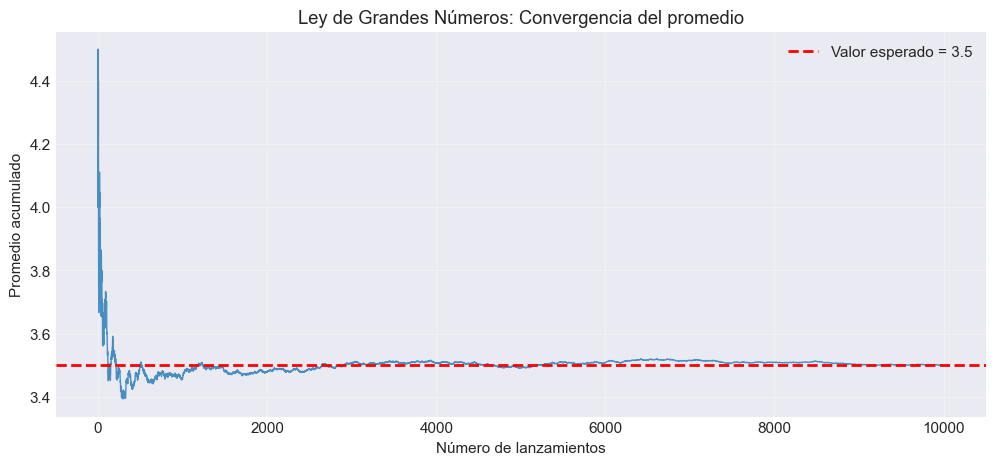

Promedio después de 10000 lanzamientos: 3.4999
Valor esperado teórico: 3.5000


In [2]:
# Demostración de la Ley de Grandes Números
# Simulamos el lanzamiento de un dado y vemos cómo converge el promedio

num_lanzamientos = 10000
lanzamientos = np.random.randint(1, 7, size=num_lanzamientos)

# Calculamos el promedio acumulado
promedios_acumulados = np.cumsum(lanzamientos) / np.arange(1, num_lanzamientos + 1)

# Visualización
plt.figure(figsize=(12, 5))
plt.plot(promedios_acumulados, linewidth=1, alpha=0.8)
plt.axhline(y=3.5, color='r', linestyle='--', linewidth=2, label='Valor esperado = 3.5')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Promedio acumulado')
plt.title('Ley de Grandes Números: Convergencia del promedio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Promedio después de {num_lanzamientos} lanzamientos: {promedios_acumulados[-1]:.4f}")
print(f"Valor esperado teórico: 3.5000")

---

## 3. Algoritmo básico de simulación Monte Carlo

### Estructura general

```
Para cada réplica i = 1, 2, ..., N:
    1. Generar valores aleatorios de las variables de entrada
    2. Evaluar el modelo (calcular la salida Y_i)
    3. Almacenar Y_i

Al finalizar:
    4. Estimar la media: E[Y] ≈ (1/N) * Σ Y_i
    5. Calcular desviación estándar: s
    6. Construir intervalo de confianza
    7. Estimar probabilidades y percentiles
```

### Implementación genérica

In [3]:
def simulacion_monte_carlo(funcion_modelo, generador_entradas, num_simulaciones, nivel_confianza=0.95):
    """
    Implementación genérica de simulación Monte Carlo.
    
    Parámetros:
        funcion_modelo: Función que evalúa el modelo (recibe entradas, devuelve salida)
        generador_entradas: Función que genera un conjunto de entradas aleatorias
        num_simulaciones: Número de réplicas
        nivel_confianza: Nivel de confianza para el intervalo (por defecto 95%)
    
    Retorna:
        resultados: Diccionario con estadísticas de la simulación
    """
    
    # Paso 1-3: Generar réplicas
    salidas = np.zeros(num_simulaciones)
    
    for i in range(num_simulaciones):
        entradas = generador_entradas()
        salidas[i] = funcion_modelo(entradas)
    
    # Paso 4: Estadísticas básicas
    media = np.mean(salidas)
    desviacion = np.std(salidas, ddof=1)
    
    # Paso 5: Intervalo de confianza
    alpha = 1 - nivel_confianza
    z_critico = stats.norm.ppf(1 - alpha/2)
    error_estandar = desviacion / np.sqrt(num_simulaciones)
    intervalo = (media - z_critico * error_estandar, media + z_critico * error_estandar)
    
    # Paso 6: Percentiles
    percentiles = {
        'p5': np.percentile(salidas, 5),
        'p25': np.percentile(salidas, 25),
        'p50': np.percentile(salidas, 50),
        'p75': np.percentile(salidas, 75),
        'p95': np.percentile(salidas, 95)
    }
    
    return {
        'salidas': salidas,
        'media': media,
        'desviacion': desviacion,
        'intervalo_confianza': intervalo,
        'percentiles': percentiles,
        'num_simulaciones': num_simulaciones
    }

---

## 4. Aplicación 1: Logística - Dimensionamiento de flota

Retomamos el problema inicial. Vamos a simular el sistema para evaluar diferentes tamaños de flota.

### Supuestos del modelo

- Demanda diaria $D \sim \text{Normal}(\mu=180, \sigma=40)$ entregas/día
- Capacidad por camión: 30 entregas/día
- Costo fijo por camión: $50,000 USD/año (equivalente a $200 USD/día considerando 250 días hábiles)
- Costo de subcontratación: $100 USD/entrega excedente
- Evaluamos el costo diario promedio para diferentes tamaños de flota

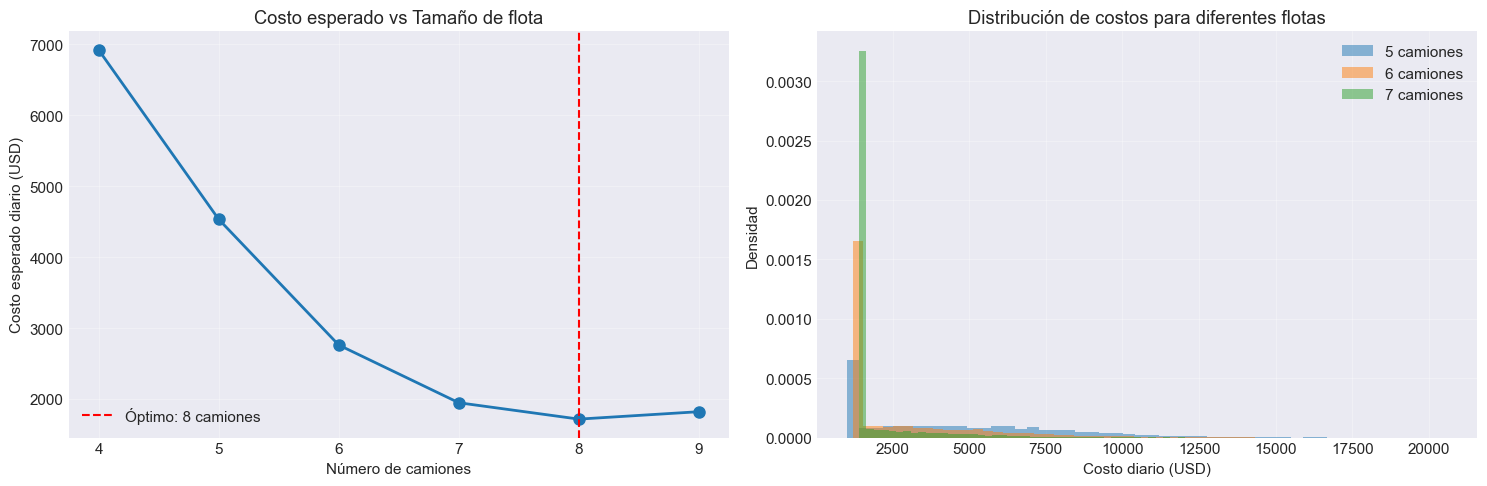

RESULTADOS DEL ANÁLISIS DE FLOTA

Tamaño óptimo de flota: 8 camiones
Costo esperado diario: $1715.50
Costo esperado anual: $428873.95
Desviación estándar: $582.41
Percentil 95 (presupuesto conservador): $2187.33

Comparación con decisión basada en promedio:
Flota basada en promedio: 6 camiones
Diferencia en costo diario: $1045.07


In [4]:
# Parámetros del problema
mu_demanda = 180  # entregas/día
sigma_demanda = 40  # entregas/día
capacidad_camion = 30  # entregas/camión
costo_fijo_diario = 200  # USD/camión/día
costo_subcontratacion = 100  # USD/entrega

def costo_flota(num_camiones, demanda):
    """
    Calcula el costo total diario dado un tamaño de flota y una demanda.
    
    Parámetros:
        num_camiones: Número de camiones en la flota
        demanda: Demanda del día (entregas)
    
    Retorna:
        costo_total: Costo del día (USD)
    """
    # Costo fijo de la flota
    costo_fijo = num_camiones * costo_fijo_diario
    
    # Capacidad total
    capacidad_total = num_camiones * capacidad_camion
    
    # Entregas que exceden la capacidad (deben subcontratarse)
    exceso = max(0, demanda - capacidad_total)
    costo_variable = exceso * costo_subcontratacion
    
    return costo_fijo + costo_variable

# Simulación para diferentes tamaños de flota
tamaños_flota = range(4, 10)  # Probamos de 4 a 9 camiones
num_simulaciones = 10000

resultados_flota = {}

for num_camiones in tamaños_flota:
    # Generamos demandas aleatorias
    demandas = np.random.normal(mu_demanda, sigma_demanda, num_simulaciones)
    # No puede haber demanda negativa
    demandas = np.maximum(demandas, 0)
    
    # Calculamos costos para cada demanda
    costos = np.array([costo_flota(num_camiones, d) for d in demandas])
    
    # Estadísticas
    resultados_flota[num_camiones] = {
        'media': np.mean(costos),
        'desviacion': np.std(costos, ddof=1),
        'p95': np.percentile(costos, 95),
        'costos': costos
    }

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Costo esperado vs tamaño de flota
medias = [resultados_flota[n]['media'] for n in tamaños_flota]
optimo = tamaños_flota[np.argmin(medias)]

axes[0].plot(tamaños_flota, medias, 'o-', linewidth=2, markersize=8)
axes[0].axvline(optimo, color='r', linestyle='--', label=f'Óptimo: {optimo} camiones')
axes[0].set_xlabel('Número de camiones')
axes[0].set_ylabel('Costo esperado diario (USD)')
axes[0].set_title('Costo esperado vs Tamaño de flota')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Distribuciones de costo para diferentes flotas
for num_camiones in [5, 6, 7]:
    axes[1].hist(resultados_flota[num_camiones]['costos'], bins=50, alpha=0.5, 
                label=f'{num_camiones} camiones', density=True)

axes[1].set_xlabel('Costo diario (USD)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de costos para diferentes flotas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resultados
print("="*70)
print("RESULTADOS DEL ANÁLISIS DE FLOTA")
print("="*70)
print(f"\nTamaño óptimo de flota: {optimo} camiones")
print(f"Costo esperado diario: ${resultados_flota[optimo]['media']:.2f}")
print(f"Costo esperado anual: ${resultados_flota[optimo]['media'] * 250:.2f}")
print(f"Desviación estándar: ${resultados_flota[optimo]['desviacion']:.2f}")
print(f"Percentil 95 (presupuesto conservador): ${resultados_flota[optimo]['p95']:.2f}")
print("\nComparación con decisión basada en promedio:")
print(f"Flota basada en promedio: {int(np.ceil(mu_demanda / capacidad_camion))} camiones")
print(f"Diferencia en costo diario: ${resultados_flota[6]['media'] - resultados_flota[optimo]['media']:.2f}")

---

## 5. Aplicación 2: Producción - Análisis de capacidad con fallas

### Contexto del problema

Una planta manufacturera opera con una máquina que produce 100 unidades/hora cuando funciona correctamente. Sin embargo:

- El tiempo entre fallas sigue una distribución **Exponencial** con media de 50 horas
- El tiempo de reparación sigue una distribución **Lognormal** con media de 4 horas y desviación de 1 hora
- La empresa debe cumplir con un pedido de 20,000 unidades en un mes (720 horas)

**Preguntas de negocio**:
1. ¿Cuál es la probabilidad de cumplir con el pedido?
2. ¿Cuántas unidades se esperan producir en promedio?
3. ¿Cuál debería ser la meta de producción para tener 95% de confiabilidad?

### Modelo de simulación

Para cada réplica, simularemos:
- Tiempos entre fallas (cuándo ocurre cada falla)
- Tiempos de reparación (cuánto se tarda en arreglar)
- Tiempo productivo total = Tiempo total - Tiempo en reparación
- Unidades producidas = Tiempo productivo × Tasa de producción

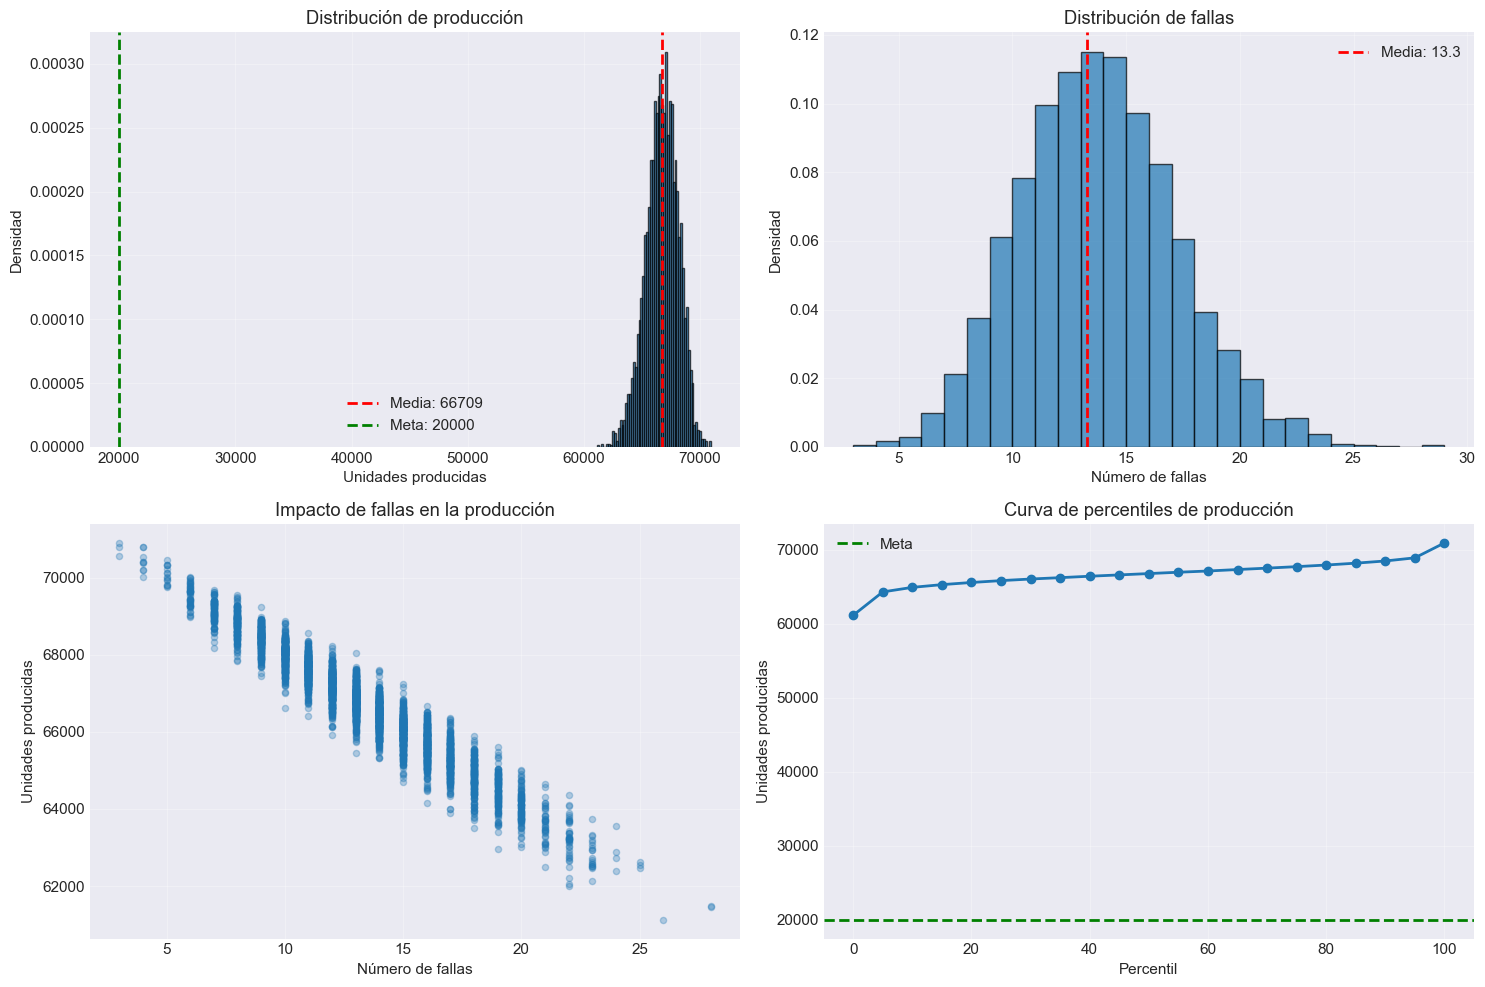

ANÁLISIS DE CAPACIDAD DE PRODUCCIÓN CON FALLAS

Escenario base:
  Horizonte de tiempo: 720 horas
  Tasa de producción: 100 unidades/hora
  Meta de producción: 20000 unidades

Resultados de la simulación (5000 réplicas):
  Producción esperada: 66709 unidades
  Intervalo de confianza 95%: [66670, 66748]
  Desviación estándar: 1398 unidades

Análisis de riesgo:
  Probabilidad de cumplir meta: 100.0%
  Percentil 5 (escenario pesimista): 64285 unidades
  Percentil 95 (escenario optimista): 68891 unidades

Análisis de fallas:
  Número promedio de fallas: 13.3
  Tiempo productivo promedio: 667.1 horas (92.7% del tiempo)

Recomendación:


In [5]:
# Parámetros del problema de producción
tasa_produccion = 100  # unidades/hora
horizonte_tiempo = 720  # horas (1 mes)
meta_produccion = 20000  # unidades
media_entre_fallas = 50  # horas
media_reparacion = 4  # horas
sigma_reparacion = 1  # horas

def simular_produccion(horizonte, tasa, media_fallas, mu_rep, sigma_rep, semilla=None):
    """
    Simula la producción de una máquina con fallas aleatorias.
    
    Parámetros:
        horizonte: Tiempo total de operación (horas)
        tasa: Unidades producidas por hora cuando funciona
        media_fallas: Tiempo promedio entre fallas (horas)
        mu_rep: Media del tiempo de reparación (horas)
        sigma_rep: Desviación estándar del tiempo de reparación (horas)
        semilla: Semilla para reproducibilidad
    
    Retorna:
        unidades_producidas: Total de unidades producidas
        num_fallas: Número de fallas ocurridas
        tiempo_productivo: Tiempo total en que la máquina estuvo operativa
    """
    if semilla is not None:
        np.random.seed(semilla)
    
    tiempo_actual = 0
    tiempo_productivo = 0
    num_fallas = 0
    
    while tiempo_actual < horizonte:
        # Tiempo hasta la próxima falla (Exponencial)
        tiempo_hasta_falla = np.random.exponential(scale=media_fallas)
        
        # ¿La falla ocurre dentro del horizonte?
        if tiempo_actual + tiempo_hasta_falla < horizonte:
            # La máquina produce hasta la falla
            tiempo_productivo += tiempo_hasta_falla
            tiempo_actual += tiempo_hasta_falla
            num_fallas += 1
            
            # Tiempo de reparación (Lognormal)
            # Para Lognormal: si queremos media=mu, usamos parámetros específicos
            # ln(media) = mu_log, y sigma_log se ajusta para la varianza deseada
            mu_log = np.log(mu_rep**2 / np.sqrt(mu_rep**2 + sigma_rep**2))
            sigma_log = np.sqrt(np.log(1 + (sigma_rep**2 / mu_rep**2)))
            tiempo_reparacion = np.random.lognormal(mean=mu_log, sigma=sigma_log)
            
            tiempo_actual += tiempo_reparacion
        else:
            # La máquina produce el tiempo restante sin fallar
            tiempo_productivo += (horizonte - tiempo_actual)
            break
    
    unidades_producidas = tiempo_productivo * tasa
    return unidades_producidas, num_fallas, tiempo_productivo

# Simulación Monte Carlo
num_simulaciones = 5000
np.random.seed(42)

resultados_produccion = {
    'unidades': [],
    'fallas': [],
    'tiempo_productivo': []
}

for i in range(num_simulaciones):
    unidades, fallas, tiempo_prod = simular_produccion(
        horizonte_tiempo, tasa_produccion, media_entre_fallas,
        media_reparacion, sigma_reparacion, semilla=42+i
    )
    resultados_produccion['unidades'].append(unidades)
    resultados_produccion['fallas'].append(fallas)
    resultados_produccion['tiempo_productivo'].append(tiempo_prod)

# Convertir a arrays
unidades = np.array(resultados_produccion['unidades'])
fallas = np.array(resultados_produccion['fallas'])
tiempo_prod = np.array(resultados_produccion['tiempo_productivo'])

# Análisis estadístico
media_unidades = np.mean(unidades)
std_unidades = np.std(unidades, ddof=1)
prob_cumplir = np.mean(unidades >= meta_produccion)
percentil_5 = np.percentile(unidades, 5)
percentil_95 = np.percentile(unidades, 95)

# Intervalo de confianza para la media
z_95 = 1.96
error_estandar = std_unidades / np.sqrt(num_simulaciones)
ic_inferior = media_unidades - z_95 * error_estandar
ic_superior = media_unidades + z_95 * error_estandar

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfica 1: Distribución de unidades producidas
axes[0, 0].hist(unidades, bins=60, density=True, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(media_unidades, color='r', linestyle='--', linewidth=2, label=f'Media: {media_unidades:.0f}')
axes[0, 0].axvline(meta_produccion, color='g', linestyle='--', linewidth=2, label=f'Meta: {meta_produccion}')
axes[0, 0].set_xlabel('Unidades producidas')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].set_title('Distribución de producción')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfica 2: Distribución de número de fallas
axes[0, 1].hist(fallas, bins=range(int(np.min(fallas)), int(np.max(fallas))+2), 
                density=True, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(np.mean(fallas), color='r', linestyle='--', linewidth=2, 
                   label=f'Media: {np.mean(fallas):.1f}')
axes[0, 1].set_xlabel('Número de fallas')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('Distribución de fallas')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Gráfica 3: Relación fallas vs producción
axes[1, 0].scatter(fallas, unidades, alpha=0.3, s=20)
axes[1, 0].set_xlabel('Número de fallas')
axes[1, 0].set_ylabel('Unidades producidas')
axes[1, 0].set_title('Impacto de fallas en la producción')
axes[1, 0].grid(True, alpha=0.3)

# Gráfica 4: Percentiles de producción
percentiles = np.percentile(unidades, range(0, 101, 5))
axes[1, 1].plot(range(0, 101, 5), percentiles, 'o-', linewidth=2, markersize=6)
axes[1, 1].axhline(meta_produccion, color='g', linestyle='--', linewidth=2, label='Meta')
axes[1, 1].set_xlabel('Percentil')
axes[1, 1].set_ylabel('Unidades producidas')
axes[1, 1].set_title('Curva de percentiles de producción')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resultados
print("="*70)
print("ANÁLISIS DE CAPACIDAD DE PRODUCCIÓN CON FALLAS")
print("="*70)
print(f"\nEscenario base:")
print(f"  Horizonte de tiempo: {horizonte_tiempo} horas")
print(f"  Tasa de producción: {tasa_produccion} unidades/hora")
print(f"  Meta de producción: {meta_produccion} unidades")
print(f"\nResultados de la simulación ({num_simulaciones} réplicas):")
print(f"  Producción esperada: {media_unidades:.0f} unidades")
print(f"  Intervalo de confianza 95%: [{ic_inferior:.0f}, {ic_superior:.0f}]")
print(f"  Desviación estándar: {std_unidades:.0f} unidades")
print(f"\nAnálisis de riesgo:")
print(f"  Probabilidad de cumplir meta: {prob_cumplir:.1%}")
print(f"  Percentil 5 (escenario pesimista): {percentil_5:.0f} unidades")
print(f"  Percentil 95 (escenario optimista): {percentil_95:.0f} unidades")
print(f"\nAnálisis de fallas:")
print(f"  Número promedio de fallas: {np.mean(fallas):.1f}")
print(f"  Tiempo productivo promedio: {np.mean(tiempo_prod):.1f} horas ({np.mean(tiempo_prod)/horizonte_tiempo*100:.1f}% del tiempo)")
print(f"\nRecomendación:")
if prob_cumplir < 0.95:
    deficit = meta_produccion - percentil_5
    print(f"  La confiabilidad es baja ({prob_cumplir:.1%}).")
    print(f"  Considerar: (1) Mantenimiento preventivo, (2) Capacidad de respaldo")
    print(f"  o (3) Aumentar la meta en {deficit:.0f} unidades para buffer.")